# EDA: Disaster Tweets — Notebook 2 (Kaggle-inspired)

**Overview.** This notebook follows an exploratory approach similar to many Kaggle EDA notebooks: more visual analysis, n-gram exploration, and hands-on exercises. It is tailored for students to practice applying common EDA techniques in NLP.

**Dataset.** Kaggle 'nlp-getting-started' (train.csv). Ensure `train.csv` is available in the working directory.

## 1) Imports & Loading

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.naive_bayes import MultinomialNB

**Load dataset**

In [ ]:

train_path = r'nlp-getting-started/train.csv'
df = pd.read_csv(train_path)
print(df.shape)
df.head()


(7613, 5)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


## 2) Sanity checks and target analysis
Check missing values, class balance, and inspect a few examples from each class.

In [4]:
print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        7613 non-null   int64
 1   keyword   7552 non-null   str  
 2   location  5080 non-null   str  
 3   text      7613 non-null   str  
 4   target    7613 non-null   int64
dtypes: int64(2), str(3)
memory usage: 1.2 MB
None


In [6]:
print('\nMissing values:\n', df.isnull().sum())


Missing values:
 id             0
keyword       61
location    2533
text           0
target         0
dtype: int64


In [7]:
print('\nClass balance:\n', df['target'].value_counts())


Class balance:
 target
0    4342
1    3271
Name: count, dtype: int64


In [8]:
# Show examples for each class
for cls in df['target'].unique():
    print('\nExample for target=', cls)
    print(df[df['target']==cls]['text'].sample(3).tolist())



Example for target= 1
['#Allah describes piling up #wealth thinking it would last #forever as the description of the people of #Hellfire in Surah Humaza. #Reflect', "@Rebelmage2 I'm glad you got away XD But My 'be safe' was in reference to a tornado near calgary and drum heller at around 4 :O", '11:30a Radar Update: Widespread Showers/Storms but moving over the same areas-minor flooding possible #HUNwx http://t.co/E3L1JqjH2u']

Example for target= 0
['Truth...\nhttps://t.co/h6amECX5K7\n#News\n#BBC\n#CNN\n#Islam\n#Truth\n#god\n#ISIS\n#terrorism\n#Quran\n#Lies http://t.co/B8iWRdxcm0', 'August 5 1620 one hundred-odd pilgrims from England and Holland set sail for the New World. They were unimpressed. http://t.co/pW5DSt9ROz', 'Enugu Government to demolish illegal structures at International Conference Centre http://t.co/7K5SHaiqIw']


## 3) Text cleaning utilities
Define reusable cleaning functions. Keep original text column intact; create `clean_text` for analysis-only.

In [9]:
def clean_text(text):
    # Remove URLs, mentions, hashtags (keep words), punctuation; lowercase
    text = str(text)
    text = re.sub(r'http\S+', '', text)   # remove urls
    text = re.sub(r'@\w+', '', text)      # mentions
    text = re.sub(r'#', '', text)          # remove hashtag symbol only
    text = re.sub(r'[^A-Za-z0-9\s]', ' ', text)  # remove punctuation
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [10]:
# Create a clean column
df['clean_text'] = df['text'].apply(clean_text)
df[['text','clean_text']].head()


,text,clean_text
0,Our Deeds are the Reason of this #earthquake M...,our deeds are the reason of this earthquake ma...
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,all residents asked to shelter in place are be...
3,"13,000 people receive #wildfires evacuation or...",13 000 people receive wildfires evacuation ord...
4,Just got sent this photo from Ruby #Alaska as ...,just got sent this photo from ruby alaska as s...


## 4) N-gram analysis (unigrams, bigrams)
Compute and compare the top unigrams and bigrams for disaster vs non-disaster tweets.

UNIGRAMS

In [12]:
vect = CountVectorizer(ngram_range=(1,1), stop_words='english', min_df=2)
X = vect.fit_transform(df['clean_text'])
sums = np.array(X.sum(axis=0)).ravel()
words = np.array(vect.get_feature_names_out())
idx = np.argsort(sums)[-25:][::-1]
print('Top unigrams (overall):')
for i in idx:
    print(words[i], sums[i])

Top unigrams (overall):
like 348
amp 344
just 323
new 227
people 199
news 196
don 192
video 165
emergency 158
disaster 158
police 143
body 131
california 121
storm 121
burning 121
crash 119
suicide 119
day 118
man 117
time 116
know 113
got 113
rt 111
buildings 111
world 106


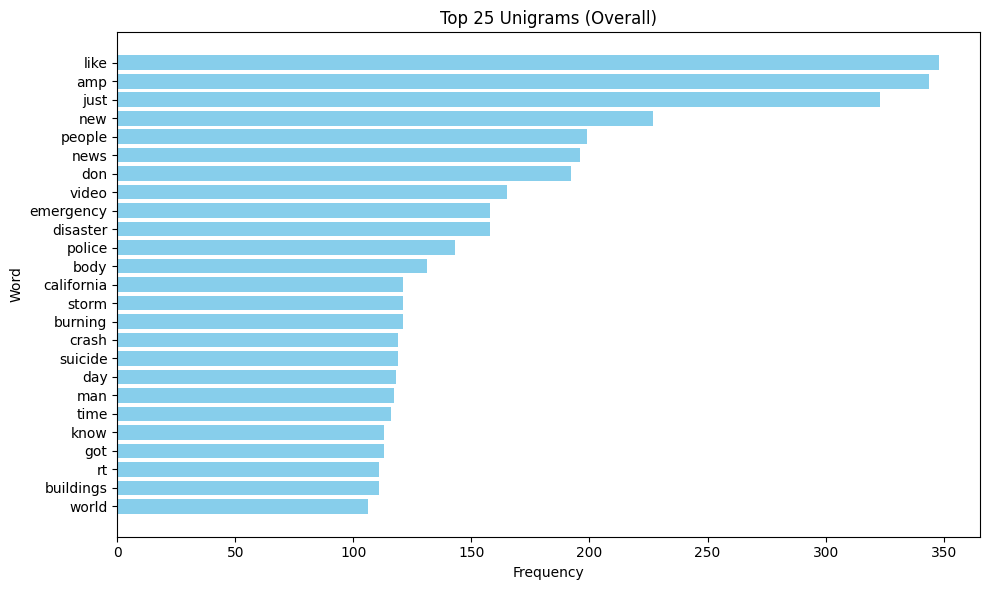

In [15]:
top_words = words[idx]
top_counts = sums[idx]

plt.figure(figsize=(10,6))
plt.barh(top_words[::-1], top_counts[::-1], color='skyblue')
plt.title("Top 25 Unigrams (Overall)")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

BIGRAMS

In [13]:
# Bigrams (students: compare by class as exercise)
vect2 = CountVectorizer(ngram_range=(2,2), stop_words='english', min_df=2)
X2 = vect2.fit_transform(df['clean_text'])
sums2 = np.array(X2.sum(axis=0)).ravel()
bigrams = np.array(vect2.get_feature_names_out())
idx2 = np.argsort(sums2)[-20:][::-1]
print('\nTop bigrams overall:')
for i in idx2:
    print(bigrams[i], sums2[i])



Top bigrams overall:
burning buildings 60
suicide bomber 59
liked video 41
northern california 41
cross body 40
oil spill 39
suicide bombing 36
california wildfire 34
year old 34
looks like 33
gt gt 32
mass murder 32
heat wave 31
natural disaster 31
mass murderer 31
70 years 31
prebreak best 30
bomber detonated 30
homes razed 29
confirmed mh370 29


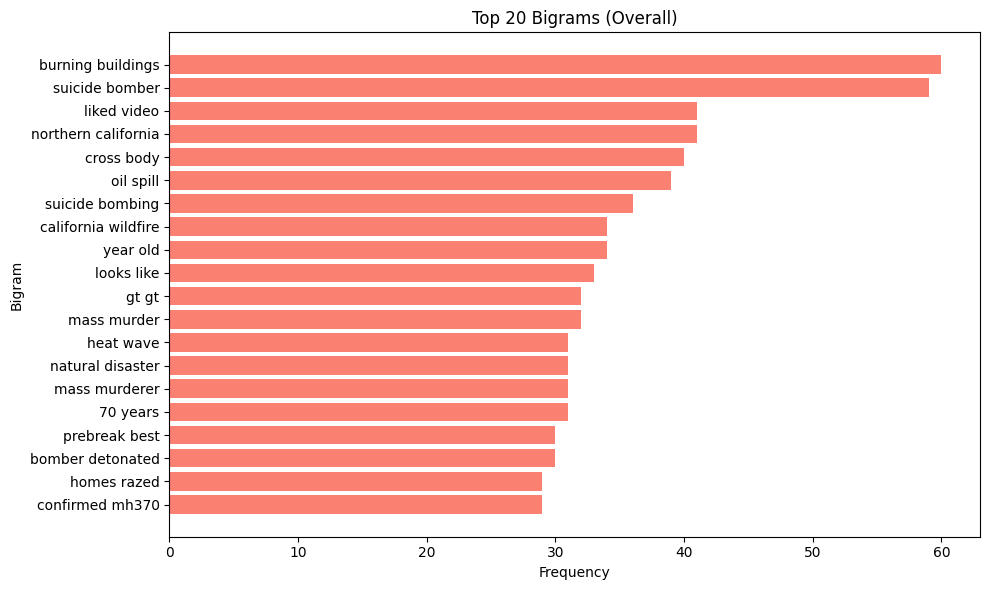

In [17]:
top_bigrams = bigrams[idx2]
top_counts = sums2[idx2]

plt.figure(figsize=(10,6))
plt.barh(top_bigrams[::-1], top_counts[::-1], color='salmon')
plt.title("Top 20 Bigrams (Overall)")
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.tight_layout()
plt.show()

## 5) Class-specific n-grams (exercise)
Exercise: compute top unigrams and bigrams for target=1 vs target=0 and visualise differences (bar plots).

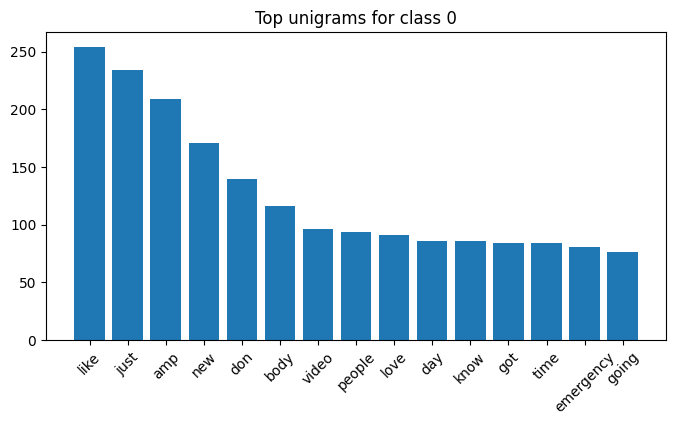

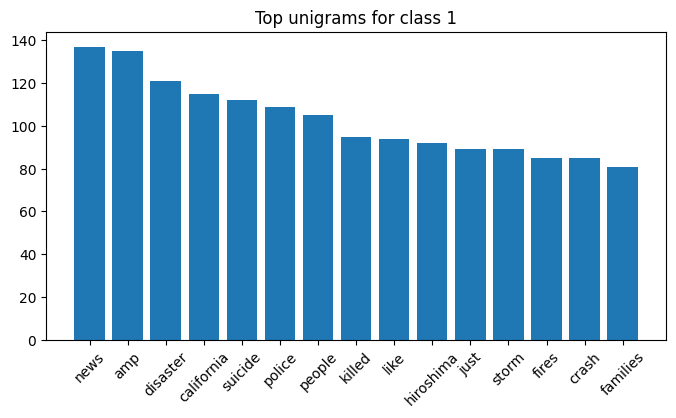

In [18]:
# Hint / partial solution for students
for cls in [0,1]:
    vec = CountVectorizer(ngram_range=(1,1), stop_words='english', min_df=2)
    Xc = vec.fit_transform(df[df['target']==cls]['clean_text'])
    sums_c = np.array(Xc.sum(axis=0)).ravel()
    words_c = np.array(vec.get_feature_names_out())
    top_idx = np.argsort(sums_c)[-15:]  # smallest to largest
    top_words = words_c[top_idx][::-1]
    top_counts = sums_c[top_idx][::-1]
    plt.figure(figsize=(8,4))
    plt.bar(top_words, top_counts)
    plt.xticks(rotation=45)
    plt.title(f'Top unigrams for class {cls}')
    plt.show()


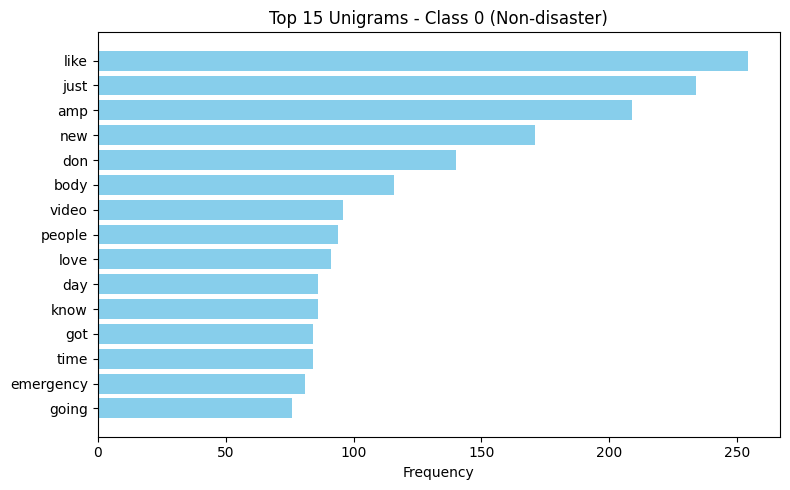

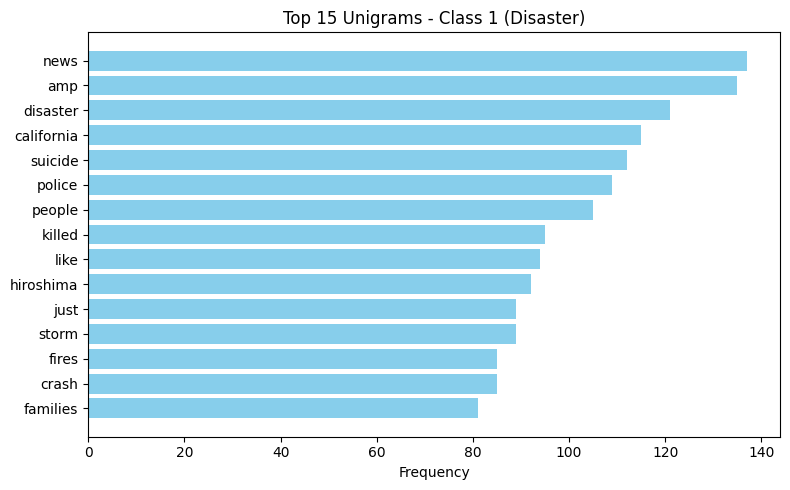

In [21]:
for cls in [0, 1]:
    
    vec = CountVectorizer(ngram_range=(1,1),
                          stop_words='english',
                          min_df=2)
    
    Xc = vec.fit_transform(df[df['target']==cls]['clean_text'])
    
    sums_c = np.array(Xc.sum(axis=0)).ravel()
    words_c = np.array(vec.get_feature_names_out())
    
    # Top 15 largest counts
    top_idx = np.argsort(sums_c)[-15:]
    top_words = words_c[top_idx]
    top_counts = sums_c[top_idx]
    
    # Sort descending
    order = np.argsort(top_counts)
    
    plt.figure(figsize=(8,5))
    plt.barh(top_words[order], top_counts[order], color='skyblue')
    plt.title(f"Top 15 Unigrams - Class {cls} ({'Non-disaster' if cls==0 else 'Disaster'})")
    plt.xlabel("Frequency")
    plt.tight_layout()
    plt.show()

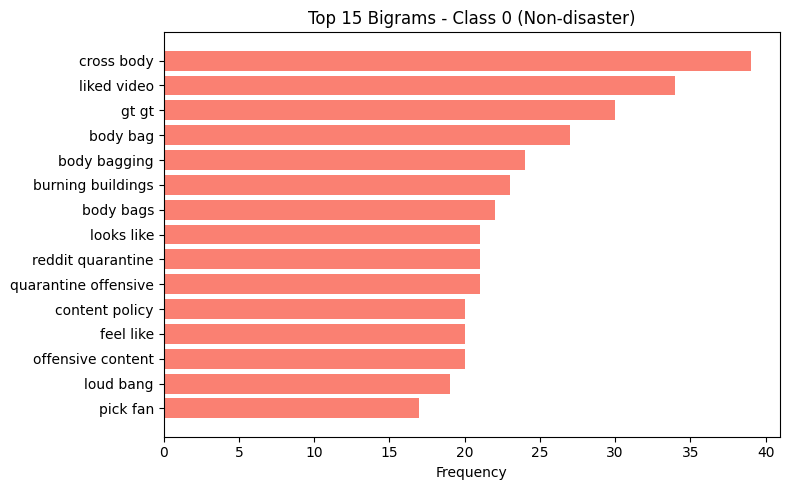

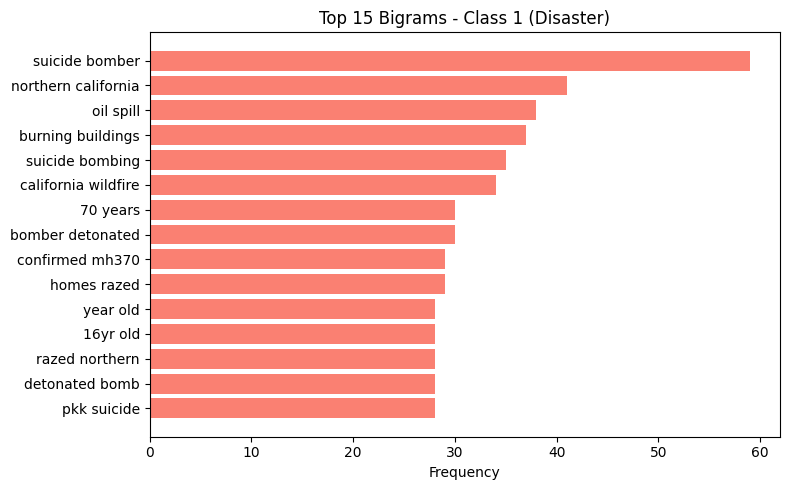

In [22]:
for cls in [0, 1]:
    
    vec = CountVectorizer(ngram_range=(2,2),
                          stop_words='english',
                          min_df=2)
    
    Xc = vec.fit_transform(df[df['target']==cls]['clean_text'])
    
    sums_c = np.array(Xc.sum(axis=0)).ravel()
    bigrams_c = np.array(vec.get_feature_names_out())
    
    top_idx = np.argsort(sums_c)[-15:]
    top_bigrams = bigrams_c[top_idx]
    top_counts = sums_c[top_idx]
    
    order = np.argsort(top_counts)
    
    plt.figure(figsize=(8,5))
    plt.barh(top_bigrams[order], top_counts[order], color='salmon')
    plt.title(f"Top 15 Bigrams - Class {cls} ({'Non-disaster' if cls==0 else 'Disaster'})")
    plt.xlabel("Frequency")
    plt.tight_layout()
    plt.show()

## 6) Correlation and feature ideas
Create simple numeric features from text (char_count, word_count, count of exclamation marks, presence of question mark) and inspect correlations with `target`.

In [41]:
# Feature engineering examples

df['char_count'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
df['excl_count'] = df['text'].apply(lambda x: str(x).count('!'))
df['has_question'] = df['text'].apply(lambda x: '?' in str(x)).astype(int)

# Group by target
print(df.groupby('target')[['char_count','word_count','excl_count','has_question']].mean())


        char_count  word_count  excl_count  has_question
target                                                  
0        95.706817   14.704744    0.194150      0.172731
1       108.113421   15.167533    0.100887      0.089269


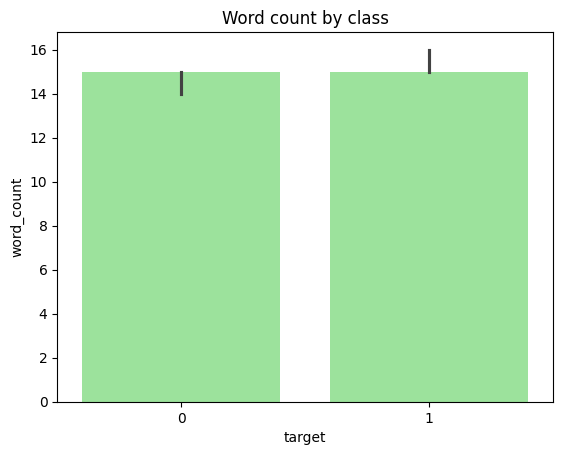

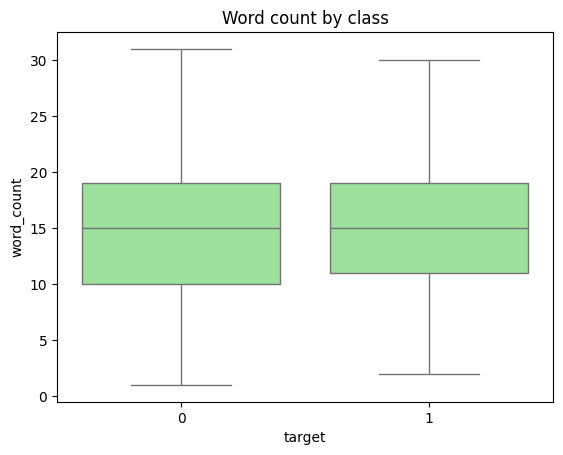

In [38]:
sns.barplot(x='target', y='word_count', data=df, estimator=np.median, color='lightgreen')
plt.title('Word count by class')
plt.show()

sns.boxplot(x='target', y='word_count', data=df, color='lightgreen')
plt.title('Word count by class')
plt.show()

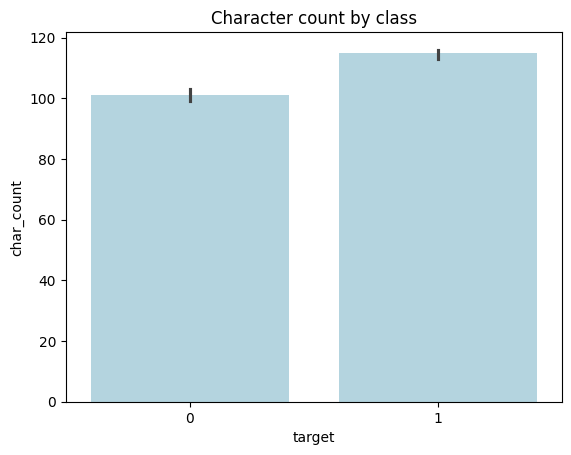

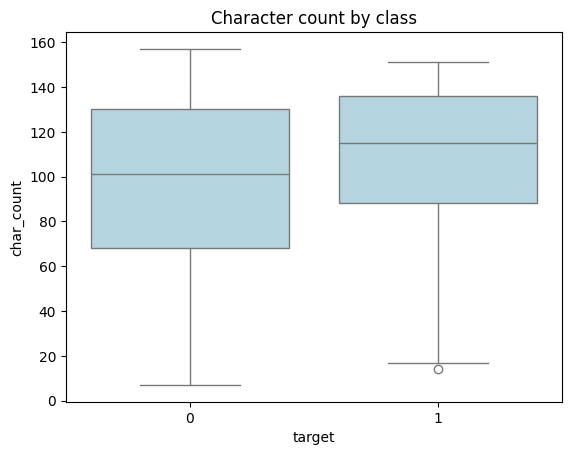

In [39]:
sns.barplot(x='target', y='char_count', data=df, estimator=np.median, color='lightblue')
plt.title('Character count by class')
plt.show()

sns.boxplot(x='target', y='char_count', data=df, color='lightblue')
plt.title('Character count by class')
plt.show()

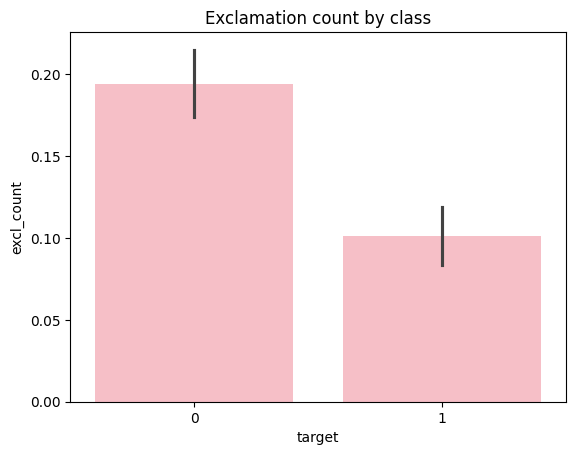

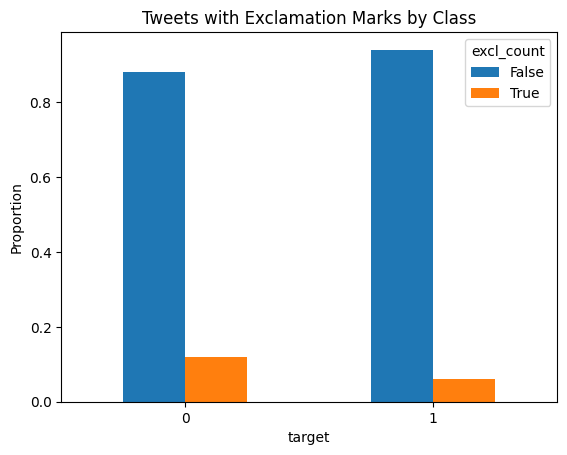

In [51]:
sns.barplot(x='target', y='excl_count', data=df,  color='lightpink')
plt.title('Exclamation count by class')
plt.show()

pd.crosstab(df['target'], df['excl_count'] > 0, normalize='index').plot(kind='bar')
plt.title("Tweets with Exclamation Marks by Class")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.show()

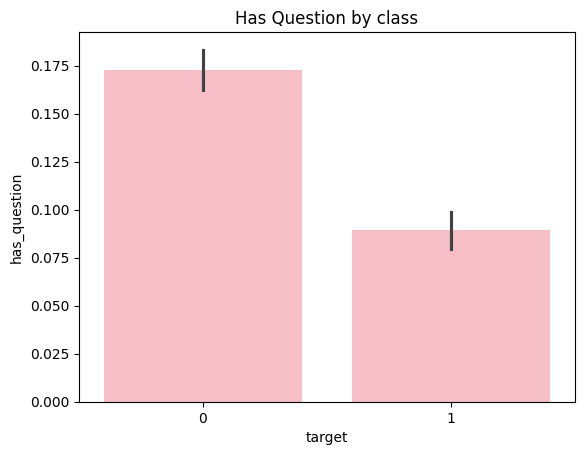

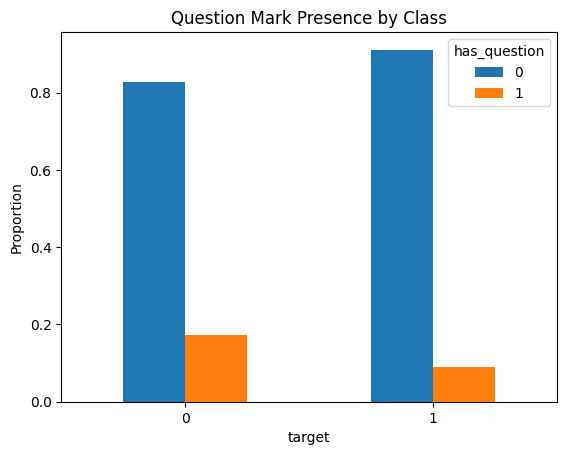

In [50]:
sns.barplot(x='target', y='has_question', data=df,  color='lightpink')
plt.title('Has Question by class')
plt.show()

pd.crosstab(df['target'], df['has_question'], normalize='index').plot(kind='bar')
plt.title("Question Mark Presence by Class")
plt.xticks(rotation=0)
plt.ylabel("Proportion")
plt.show()

## 7) Practical exercises (Notebook 2)
1. Compute TF-IDF features and find the top tokens by average TF-IDF for each class.
2. Build a simple Logistic Regression baseline (use CountVectorizer or TF-IDF) and report accuracy and F1-score. Compare to a Naive Bayes baseline.
3. Create a function to detect presence of location words (simple gazetteer from `location` column) and test whether tweets mentioning cities are more likely to be disaster-related.

*Provide short written answers explaining your steps and findings.*

----
*End of Notebook 2 — instructors may expand exercises or provide test datasets for grading.*

**Section 1:** Compute TF-IDF features and show top words by class

In [53]:
tfidf = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1,1),
    min_df=2
)

X_tfidf = tfidf.fit_transform(df['clean_text'])
y = df['target'].values

In [55]:
feature_names = np.array(tfidf.get_feature_names_out())

# Separate by class
X_dis = X_tfidf[y == 1]
X_non = X_tfidf[y == 0]

# Mean TF-IDF per token
mean_dis = np.asarray(X_dis.mean(axis=0)).ravel()
mean_non = np.asarray(X_non.mean(axis=0)).ravel()

In [57]:
top_dis_idx = np.argsort(mean_dis)[-20:][::-1]
top_non_idx = np.argsort(mean_non)[-20:][::-1]

print("Top TF-IDF tokens - Disaster")
for i in top_dis_idx:
    print(feature_names[i], round(mean_dis[i], 4))



Top TF-IDF tokens - Disaster
california 0.0098
news 0.0096
disaster 0.0092
suicide 0.0086
hiroshima 0.0084
amp 0.0078
fires 0.0078
storm 0.0076
police 0.0076
killed 0.0074
people 0.0073
crash 0.0072
mh370 0.007
families 0.0069
buildings 0.0069
like 0.0068
wildfire 0.0067
train 0.0065
bombing 0.0062
nuclear 0.0062


In [58]:
print("\nTop TF-IDF tokens - Non-Disaster")
for i in top_non_idx:
    print(feature_names[i], round(mean_non[i], 4))


Top TF-IDF tokens - Non-Disaster
like 0.0138
just 0.013
amp 0.0098
new 0.009
don 0.0088
body 0.0072
love 0.0071
know 0.006
got 0.0058
video 0.0058
day 0.0057
people 0.0056
time 0.0056
let 0.0055
going 0.0052
think 0.0049
lol 0.0048
want 0.0047
emergency 0.0047
good 0.0047


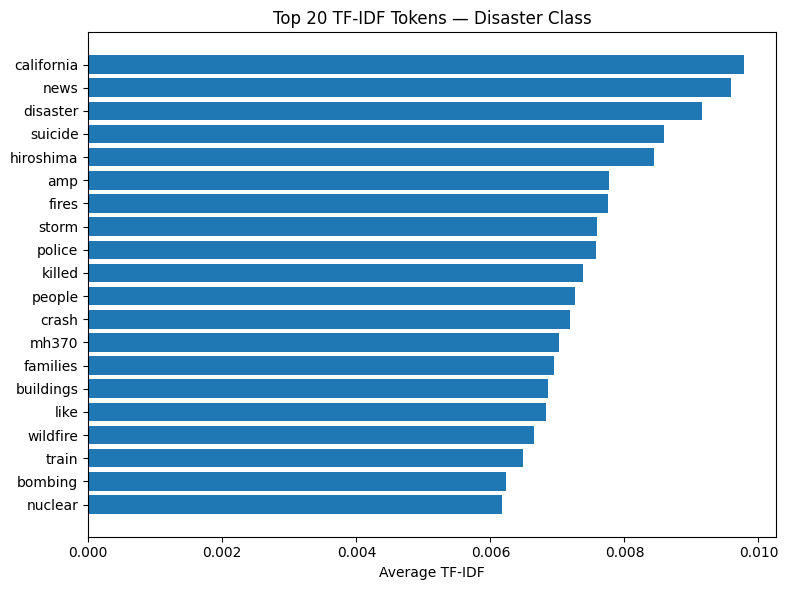

In [ ]:
top_k = 20

top_dis_idx = np.argsort(mean_dis)[-top_k:]
top_dis_words = feature_names[top_dis_idx]
top_dis_scores = mean_dis[top_dis_idx]

order = np.argsort(top_dis_scores)

plt.figure(figsize=(8,6))
plt.barh(top_dis_words[order], top_dis_scores[order])
plt.title("Top 20 TF-IDF Tokens — Disaster Class")
plt.xlabel("Average TF-IDF")
plt.tight_layout()
plt.show()

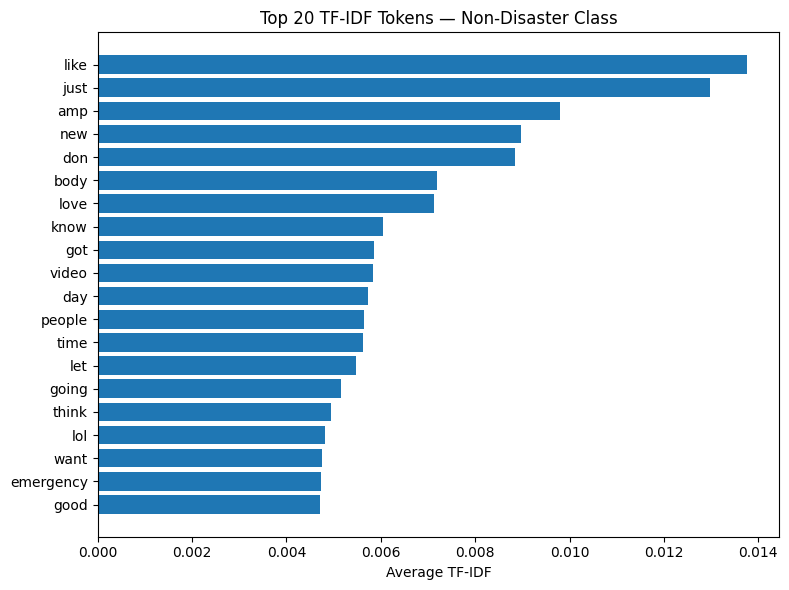

In [61]:
top_non_idx = np.argsort(mean_non)[-top_k:]
top_non_words = feature_names[top_non_idx]
top_non_scores = mean_non[top_non_idx]

order = np.argsort(top_non_scores)

plt.figure(figsize=(8,6))
plt.barh(top_non_words[order], top_non_scores[order])
plt.title("Top 20 TF-IDF Tokens — Non-Disaster Class")
plt.xlabel("Average TF-IDF")
plt.tight_layout()
plt.show()

**Section 2:** Build a simple Logistic Regression baseline (use CountVectorizer or TF-IDF) and report accuracy and F1-score. Compare to a Naive Bayes baseline.

In [63]:
X = X_tfidf   
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [67]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("Logistic Regression")
print("Accuracy:", round(acc_lr, 4))
print("F1-score:", round(f1_lr, 4))

Logistic Regression
Accuracy: 0.8188
F1-score: 0.7661


In [68]:
nb = MultinomialNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

acc_nb = accuracy_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print("\nNaive Bayes")
print("Accuracy:", round(acc_nb, 4))
print("F1-score:", round(f1_nb, 4))


Naive Bayes
Accuracy: 0.8109
F1-score: 0.7596


Logistic Regression achieved an accuracy of 0.8188 and F1-score of 0.7661, slightly outperforming Naive Bayes (accuracy 0.8109, F1-score 0.7596). The small but consistent improvement suggests that Logistic Regression better captures discriminative lexical patterns in TF-IDF space. Overall, both models perform strongly, indicating that textual features provide substantial predictive signal for disaster classification.

**Section 3:** Create a function to detect presence of location words (simple gazetteer from `location` column) and test whether tweets mentioning cities are more likely to be disaster-related.

In [ ]:
df_loc = df.copy()  

locations = df_loc['location'].dropna().str.lower()

location_tokens = set()

for loc in locations:
    tokens = re.findall(r'[a-z]+', loc)
    for t in tokens:
        if len(t) > 2:
            location_tokens.add(t)

print("Number of location tokens:", len(location_tokens))

Number of location tokens: 2888


In [70]:
def contains_location(text):
    tokens = re.findall(r'[a-z]+', text.lower())
    return int(any(t in location_tokens for t in tokens))

df['mentions_location_word'] = df['text'].apply(contains_location)

In [71]:
pd.crosstab(
    df['target'], 
    df['mentions_location_word'], 
    normalize='index'
)

mentions_location_word,0,1
target,,
0,0.043759,0.956241
1,0.016509,0.983491


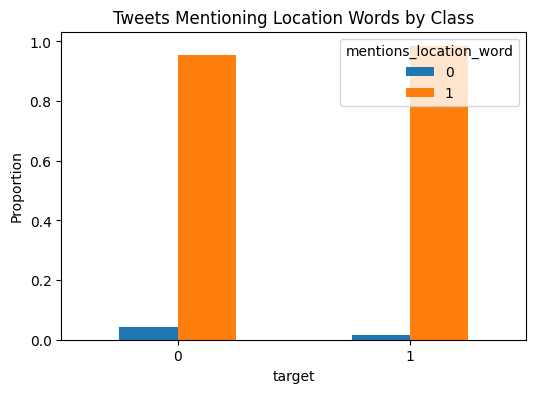

In [72]:
pd.crosstab(
    df['target'], 
    df['mentions_location_word'], 
    normalize='index'
).plot(kind='bar', figsize=(6,4))

plt.title("Tweets Mentioning Location Words by Class")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.show()

The analysis shows that a very high proportion of tweets in both classes contain at least one word from the location-based gazetteer. However, the difference between disaster and non-disaster tweets is minimal, indicating that simple presence of location words does not strongly predict disaster-related content. 